## **CAPSTONE PROJECT**

## **PREDICTIVE QUALITY CONTROL OF MACHINED SHAFTS**

In [ ]:
# CELL 1

!pip install PyWavelets tensorflow

In [ ]:
# CELL 2
#IMPORTING ALL REQUIRED LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import kurtosis, skew
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pywt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
# CELL 3
#UPLOAD DATASET

from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

raw = np.load(file_name, allow_pickle=True)

data = raw['data']
labels = raw['labels']

print("Data Shape:", data.shape)
print("Total Samples:", len(labels))

print("\nClass Distribution:")
for label, count in sorted(collections.Counter(labels).items()):
    print(f"{label}: {count}")

Saving CWRU_48k_load_1_CNN_data.npz to CWRU_48k_load_1_CNN_data.npz
Data Shape: (4600, 32, 32)
Total Samples: 4600

Class Distribution:
Ball_007: 460
Ball_014: 460
Ball_021: 460
IR_007: 460
IR_014: 460
IR_021: 460
Normal: 460
OR_007: 460
OR_014: 460
OR_021: 460


## Encode Class Labels

In [ ]:
# CELL 4

X_raw = data.reshape(len(data), -1).astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(labels)

print("Classes:", le.classes_)

Classes: ['Ball_007' 'Ball_014' 'Ball_021' 'IR_007' 'IR_014' 'IR_021' 'Normal'
 'OR_007' 'OR_014' 'OR_021']


## Split Dataset into Train and Test Sets

In [ ]:
# CELL 5

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

data_train = X_train_raw.reshape(-1, 32, 32)
data_test = X_test_raw.reshape(-1, 32, 32)

print("Train Samples:", len(y_train))
print("Test Samples:", len(y_test))

Train Samples: 3680
Test Samples: 920


##Time Domain Feature Extraction Function


In [ ]:
# CELL 6
def extract_time_features(signal):
    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    return {
        'Mean': np.mean(signal),
        'Std': np.std(signal),
        'RMS': rms,
        'Kurtosis': kurtosis(signal),
        'Skewness': skew(signal),
        'Peak': peak,
        'Crest_Factor': peak / (rms + 1e-10)
    }

## Frequency Domain Feature Extraction Function

In [ ]:
# CELL 7
SAMPLING_RATE = 48000

def extract_freq_features(signal):
    fft_vals = np.abs(np.fft.rfft(signal))
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/SAMPLING_RATE)

    low = fft_vals[fft_freqs < 5000]
    mid = fft_vals[(fft_freqs >= 5000) & (fft_freqs < 15000)]
    high = fft_vals[fft_freqs >= 15000]

    return {
        'Peak_Frequency': fft_freqs[np.argmax(fft_vals)],
        'Mean_Frequency': np.sum(fft_freqs * fft_vals) / (np.sum(fft_vals)+1e-10),
        'Total_Energy': np.sum(fft_vals**2),
        'Low_Band_Energy': np.sum(low**2),
        'Mid_Band_Energy': np.sum(mid**2),
        'High_Band_Energy': np.sum(high**2),
        'Spectral_Std': np.std(fft_vals)
    }

## Wavelet Packet Transform (WPT) Feature Extraction Function

In [ ]:
# CELL 8
def extract_wpt_features(signal):
    wp = pywt.WaveletPacket(data=signal, wavelet='db4', maxlevel=3)
    nodes = ['aaa','aad','ada','add','daa','dad','dda','ddd']
    feats = {}
    for node in nodes:
        values = wp[node].data
        feats[f'{node}_Energy'] = np.sum(values**2)
        feats[f'{node}_Std'] = np.std(values)
    return feats

## Build Feature DataFrame Function

In [ ]:
# CELL 9
def build_df(dataset, extractor):
    return pd.DataFrame([
        extractor(dataset[i].flatten())
        for i in range(len(dataset))
    ])

## Extract Time Domain Features

In [ ]:
# CELL 10
print("Extracting Time Features...")
df_time_tr = build_df(data_train, extract_time_features)
df_time_te = build_df(data_test, extract_time_features)
print(df_time_tr.shape)

Extracting Time Features...
(3680, 7)


## Extract Frequency Domain Features

In [ ]:
# CELL 11
print("Extracting Frequency Features...")
df_freq_tr = build_df(data_train, extract_freq_features)
df_freq_te = build_df(data_test, extract_freq_features)
print(df_freq_tr.shape)

Extracting Frequency Features...
(3680, 7)


## Extract WPT Features

In [ ]:
# CELL 12
print("Extracting WPT Features...")
df_wpt_tr = build_df(data_train, extract_wpt_features)
df_wpt_te = build_df(data_test, extract_wpt_features)
print(df_wpt_tr.shape)

Extracting WPT Features...
(3680, 16)


## Creating Feature Sets Dictionary

In [ ]:
# CELL 13
feature_sets = {
    "Time Domain": (df_time_tr, df_time_te),
    "Frequency Domain": (df_freq_tr, df_freq_te),
    "WPT": (df_wpt_tr, df_wpt_te)
}

## Evaluate Feature Sets using Random Forest

In [ ]:
# CELL 14
results = {}

for name, (tr, te) in feature_sets.items():
    scaler = MinMaxScaler()
    X_tr = scaler.fit_transform(tr)
    X_te = scaler.transform(te)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_tr, y_train)

    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds) * 100

    results[name] = acc
    print(f"{name}: {acc:.2f}%")

Time Domain: 88.70%
Frequency Domain: 89.02%
WPT: 93.26%


## Select Best Feature Set

In [ ]:
# CELL 15
best_name = max(results, key=results.get)

print("Best Feature Set:", best_name)
print("Accuracy:", results[best_name])

Best Feature Set: WPT
Accuracy: 93.26086956521739


## Normalize Best Feature Set

In [ ]:
# CELL 16
best_tr, best_te = feature_sets[best_name]

scaler = MinMaxScaler()
X_train_best = scaler.fit_transform(best_tr)
X_test_best = scaler.transform(best_te)

print(X_train_best.shape)
print(X_test_best.shape)

(3680, 16)
(920, 16)


## Train Random Forest Model

In [ ]:
# CELL 17
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train_best, y_train)

rf_preds = rf_model.predict(X_test_best)

rf_acc = accuracy_score(y_test, rf_preds) * 100

print("RF Accuracy:", rf_acc)

print(classification_report(
    y_test,
    rf_preds,
    target_names=le.classes_
))

RF Accuracy: 93.26086956521739
              precision    recall  f1-score   support

    Ball_007       0.75      0.90      0.82        92
    Ball_014       0.91      0.89      0.90        92
    Ball_021       0.96      0.93      0.95        92
      IR_007       1.00      1.00      1.00        92
      IR_014       1.00      1.00      1.00        92
      IR_021       0.97      0.99      0.98        92
      Normal       1.00      1.00      1.00        92
      OR_007       0.99      0.99      0.99        92
      OR_014       0.81      0.65      0.72        92
      OR_021       0.95      0.97      0.96        92

    accuracy                           0.93       920
   macro avg       0.93      0.93      0.93       920
weighted avg       0.93      0.93      0.93       920



## Preparing Labels for MLP Model

In [ ]:
# CELL 18
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

num_classes = len(le.classes_)

## Building MLP Model Architecture

In [ ]:
# CELL 19
mlp_model = Sequential()

mlp_model.add(Dense(256, activation='relu', input_shape=(X_train_best.shape[1],)))
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(64, activation='relu'))
mlp_model.add(Dense(num_classes, activation='softmax'))

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,154 (180.29 KB)

 Trainable params: 46,154 (180.29 KB)

 Non-trainable params: 0 (0.00 B)

## Train MLP Model

In [ ]:
# CELL 20
history = mlp_model.fit(
    X_train_best,
    y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3638 - loss: 1.7123 - val_accuracy: 0.6970 - val_loss: 0.9793
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6868 - loss: 0.8147 - val_accuracy: 0.7283 - val_loss: 0.6529
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7198 - loss: 0.6643 - val_accuracy: 0.7201 - val_loss: 0.6176
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7541 - loss: 0.5943 - val_accuracy: 0.7880 - val_loss: 0.5146
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7717 - loss: 0.5412 - val_accuracy: 0.8003 - val_loss: 0.4891
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7826 - loss: 0.5027 - val_accuracy: 0.8315 - val_loss: 0.4702
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7959 - loss: 0.4773 - val_accuracy: 0.8302 - val_loss: 0.4227
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8118 - loss: 0.4409 - val_accuracy: 0.8166 - val_loss:

## Evaluate MLP Model

In [ ]:
# CELL 21
loss, mlp_acc = mlp_model.evaluate(X_test_best, y_test_cat)

print("MLP Accuracy:", mlp_acc * 100)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9272 - loss: 0.1926  
MLP Accuracy: 92.7173912525177


## Compare Random Forest and MLP Performance

In [ ]:
# CELL 22
print("Random Forest Accuracy:", rf_acc)
print("MLP Accuracy:", mlp_acc * 100)

Random Forest Accuracy: 93.26086956521739
MLP Accuracy: 92.7173912525177


## Plot Feature Set Accuracy Comparison

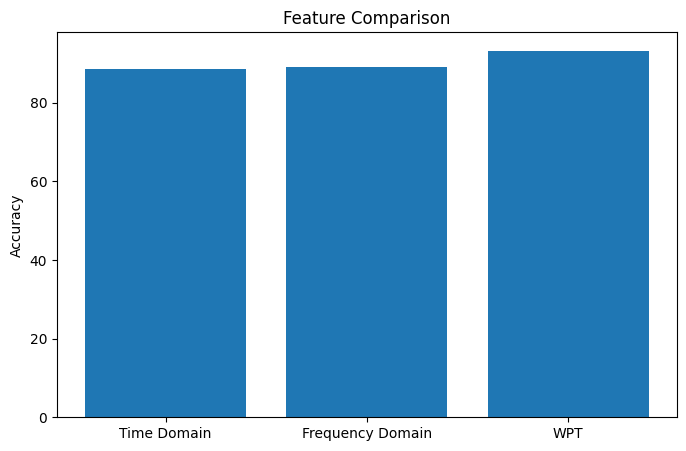

In [ ]:
# CELL 23
plt.figure(figsize=(8,5))

names = list(results.keys())
accs = list(results.values())

plt.bar(names, accs)
plt.ylabel("Accuracy")
plt.title("Feature Comparison")
plt.show()

## Plot Confusion Matrix

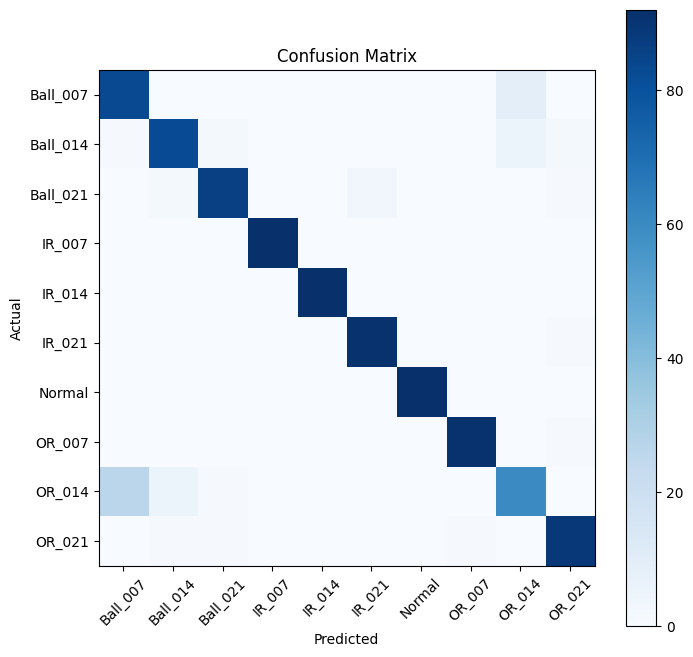

In [ ]:
# CELL 24
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks(range(len(le.classes_)), le.classes_, rotation=45)
plt.yticks(range(len(le.classes_)), le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()